# 4. Bivariate

Continues from [0_load_and_orient.ipynb](0_load_and_orient.ipynb) — reloads
the same setup so this notebook runs standalone. Builds on the flags raised
in [3_univariate.ipynb](3_univariate.ipynb).

No test-set section here — `SalePrice` doesn't exist in `test.csv`, so
everything in this notebook runs on `df_train` only.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
# load csv data — train only, bivariate needs the target column
df_train = pd.read_csv("../../data/train.csv")


In [3]:
# Feature type categorization, from data_description.txt
# each list is sorted() so the final order is alphabetical regardless of
# how the source below groups them (kept grouped here for readability)

IDENTIFIER = ["Id"]
TARGET = ["SalePrice"]

NUMERIC_COLS = sorted([
    "LotFrontage", "LotArea", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2",
    "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF",
    "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath",
    "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces",
    "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF",
    "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal",
    # temporal — usually engineered into ages/deltas rather than used raw
    "YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold",
])

# has a genuine order -> integer-encode in that order, don't one-hot
ORDINAL_COLS = sorted([
    "OverallQual", "OverallCond", "LotShape", "LandSlope",
    "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure",
    "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual",
    "Functional", "FireplaceQu", "GarageFinish", "GarageQual",
    "GarageCond", "PavedDrive", "PoolQC", "Utilities",
])

# no inherent order -> one-hot/dummy encode
NOMINAL_COLS = sorted([
    "MSSubClass",  # gotcha: stored as int, but it's a dwelling-type code
    "MSZoning", "Street", "Alley", "LandContour", "LotConfig",
    "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle",
    "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "MasVnrType",
    "Foundation", "Heating", "CentralAir", "Electrical", "GarageType",
    "MiscFeature", "SaleType", "SaleCondition", "Fence",
])

all_cols = NUMERIC_COLS + ORDINAL_COLS + NOMINAL_COLS
expected = set(df_train.columns) - set(IDENTIFIER) - set(TARGET)
assert set(all_cols) == expected, set(all_cols) ^ expected
assert len(all_cols) == len(expected)  # no duplicates
len(NUMERIC_COLS), len(ORDINAL_COLS), len(NOMINAL_COLS)


(33, 21, 25)

In [4]:
# documented level order, worst -> best, per data_description.txt — same
# map as 3_univariate.ipynb, needed again here to Spearman-rank ordinals
# against the target on their intended scale rather than raw string order
ORDER = {
    "OverallQual": list(range(1, 11)),
    "OverallCond": list(range(1, 11)),
    "LotShape": ["IR3", "IR2", "IR1", "Reg"],
    "LandSlope": ["Sev", "Mod", "Gtl"],
    "ExterQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "ExterCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "BsmtExposure": ["No", "Mn", "Av", "Gd"],
    "BsmtFinType1": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "BsmtFinType2": ["Unf", "LwQ", "Rec", "BLQ", "ALQ", "GLQ"],
    "HeatingQC": ["Po", "Fa", "TA", "Gd", "Ex"],
    "KitchenQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "Functional": ["Sal", "Sev", "Maj2", "Maj1", "Mod", "Min2", "Min1", "Typ"],
    "FireplaceQu": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageFinish": ["Unf", "RFn", "Fin"],
    "GarageQual": ["Po", "Fa", "TA", "Gd", "Ex"],
    "GarageCond": ["Po", "Fa", "TA", "Gd", "Ex"],
    "PavedDrive": ["N", "P", "Y"],
    "PoolQC": ["Fa", "TA", "Gd", "Ex"],
    "Utilities": ["ELO", "NoSeWa", "NoSewr", "AllPub"],
}

assert set(ORDER.keys()) == set(ORDINAL_COLS)

# integer-encode each ordinal column on its documented scale (NaN stays NaN
# — structural absence isn't a rank position, see 2_missingness.ipynb)
ordinal_encoded = pd.DataFrame({
    col: df_train[col].map({level: i for i, level in enumerate(ORDER[col])})
    for col in ORDINAL_COLS
})


In [5]:
# log1p target, same definition as 1_target_variable.ipynb — modeling
# happens in this space, so bivariate relationships should be read here too
log_sale_price = pd.Series(np.log1p(df_train["SalePrice"]), name="log_sale_price")
log_sale_price.head()

0    12.247699
1    12.109016
2    12.317171
3    11.849405
4    12.429220
Name: log_sale_price, dtype: float64

## Numeric features

Each of the 33 `NUMERIC_COLS` against the target, raw `SalePrice` and
`log_sale_price` side by side. **Not** an argument for logging the target —
that's already settled by the RMSLE metric in
[1_target_variable.ipynb](1_target_variable.ipynb). The question here is
narrower: given modeling happens in log space, which individual features
still look nonlinear or skewed against `log_sale_price` and are candidates
for their own transform (per the skew/zero-heavy flags already raised in
[3_univariate.ipynb](3_univariate.ipynb))?

**Scope:** flag transform candidates — don't transform here, that's
preprocessing.

In [6]:
# zero-share for every continuous numeric column, sorted descending — the
# split below is built from this table, not inherited from 3_univariate's
# prose groupings, which turn out to have misfiled two columns into
# "presence/absence" without checking pct_zero for each member individually
TEMPORAL_COLS = ["YearBuilt", "YearRemodAdd", "GarageYrBlt", "MoSold", "YrSold"]
CONTINUOUS_NUMERIC_COLS = [c for c in NUMERIC_COLS if c not in TEMPORAL_COLS]

zero_share = (df_train[CONTINUOUS_NUMERIC_COLS] == 0).mean().sort_values(ascending=False)
zero_share


PoolArea         0.995205
3SsnPorch        0.983562
LowQualFinSF     0.982192
MiscVal          0.964384
BsmtHalfBath     0.943836
ScreenPorch      0.920548
BsmtFinSF2       0.885616
EnclosedPorch    0.857534
HalfBath         0.625342
MasVnrArea       0.589726
BsmtFullBath     0.586301
2ndFlrSF         0.567808
WoodDeckSF       0.521233
Fireplaces       0.472603
OpenPorchSF      0.449315
BsmtFinSF1       0.319863
BsmtUnfSF        0.080822
GarageArea       0.055479
GarageCars       0.055479
TotalBsmtSF      0.025342
FullBath         0.006164
BedroomAbvGr     0.004110
KitchenAbvGr     0.000685
1stFlrSF         0.000000
LotFrontage      0.000000
LotArea          0.000000
GrLivArea        0.000000
TotRmsAbvGrd     0.000000
dtype: float64

**Two misfiles caught here, both inherited unchecked from
[3_univariate.ipynb](3_univariate.ipynb)'s "presence/absence" prose list:**

- `LotArea` has **0%** zero share — it was flagged there by its skew (12.2),
  not by being zero-heavy. Every house has a lot; there's no "has a lot"
  split to make. It belongs with the size-driven columns below, as a plain
  log-transform candidate.
- `KitchenAbvGr` has **0.07%** zero share — 95.3% of rows are the single
  value `1`. That's a lopsided mode, not zero-inflation; a has-X split on
  it produces a 1-row "none" group. It gets the same lopsided-level
  treatment as the 13 ordinal columns flagged in 3_univariate, not a
  presence/absence split.

The zero-share table above also settles where the amenity-driven columns
stop and the merely-skewed ones start: `WoodDeckSF`/`OpenPorchSF`/
`Fireplaces` sit at 45–52% zero, then there's a real gap down to
`BsmtFinSF1` at 32% (continuous) and `GarageCars` at 5.5% (counts). 40% is
used as the cutoff below — it falls in that gap, so nothing near the
boundary is an arbitrary call.

One more axis, orthogonal to zero-inflation: `BsmtFullBath`, `HalfBath`,
`BsmtHalfBath`, and `Fireplaces` are low-cardinality *counts* (3–4 distinct
values), not continuous square footage — a boxplot by level reads better
than a scatter with 3–4 possible x-positions, same as the presence/absence
split's "nonzero subset" panel would if applied to a count.

In [7]:
# continuous, amenity-driven zero share (>40%, see the gap noted above)
ZERO_INFLATED_CONTINUOUS = sorted([
    "MasVnrArea", "2ndFlrSF", "EnclosedPorch", "ScreenPorch", "BsmtFinSF2",
    "3SsnPorch", "LowQualFinSF", "PoolArea", "MiscVal", "WoodDeckSF",
    "OpenPorchSF",
])

# low-cardinality counts, amenity-driven zero share (>40%)
ZERO_INFLATED_COUNTS = sorted(["BsmtFullBath", "HalfBath", "BsmtHalfBath", "Fireplaces"])

# lopsided, not zero-driven — same chart as the counts above (boxplot by
# level), different reason for the skewed level distribution
LOPSIDED_COUNTS = ["KitchenAbvGr"]

# whatever's left splits by cardinality, same DISCRETE_THRESHOLD=15 rule
# 3_univariate.ipynb used for histogram-vs-bar — not zero-driven, but a
# scatter with 4-12 possible x-positions (FullBath, GarageCars,
# BedroomAbvGr, TotRmsAbvGrd) is just as uninformative as one on a count
# that happens to be zero-heavy, so it gets the same boxplot treatment
DISCRETE_THRESHOLD = 15
remaining = [
    c for c in CONTINUOUS_NUMERIC_COLS
    if c not in ZERO_INFLATED_CONTINUOUS
    and c not in ZERO_INFLATED_COUNTS
    and c not in LOPSIDED_COUNTS
]
nunique_remaining = df_train[remaining].nunique()
DISCRETE_COUNT_COLS = sorted(nunique_remaining[nunique_remaining <= DISCRETE_THRESHOLD].index)
SIZE_COLS = sorted(nunique_remaining[nunique_remaining > DISCRETE_THRESHOLD].index)

len(SIZE_COLS), len(ZERO_INFLATED_CONTINUOUS), len(ZERO_INFLATED_COUNTS), len(LOPSIDED_COUNTS), len(DISCRETE_COUNT_COLS)


(8, 11, 4, 1, 4)

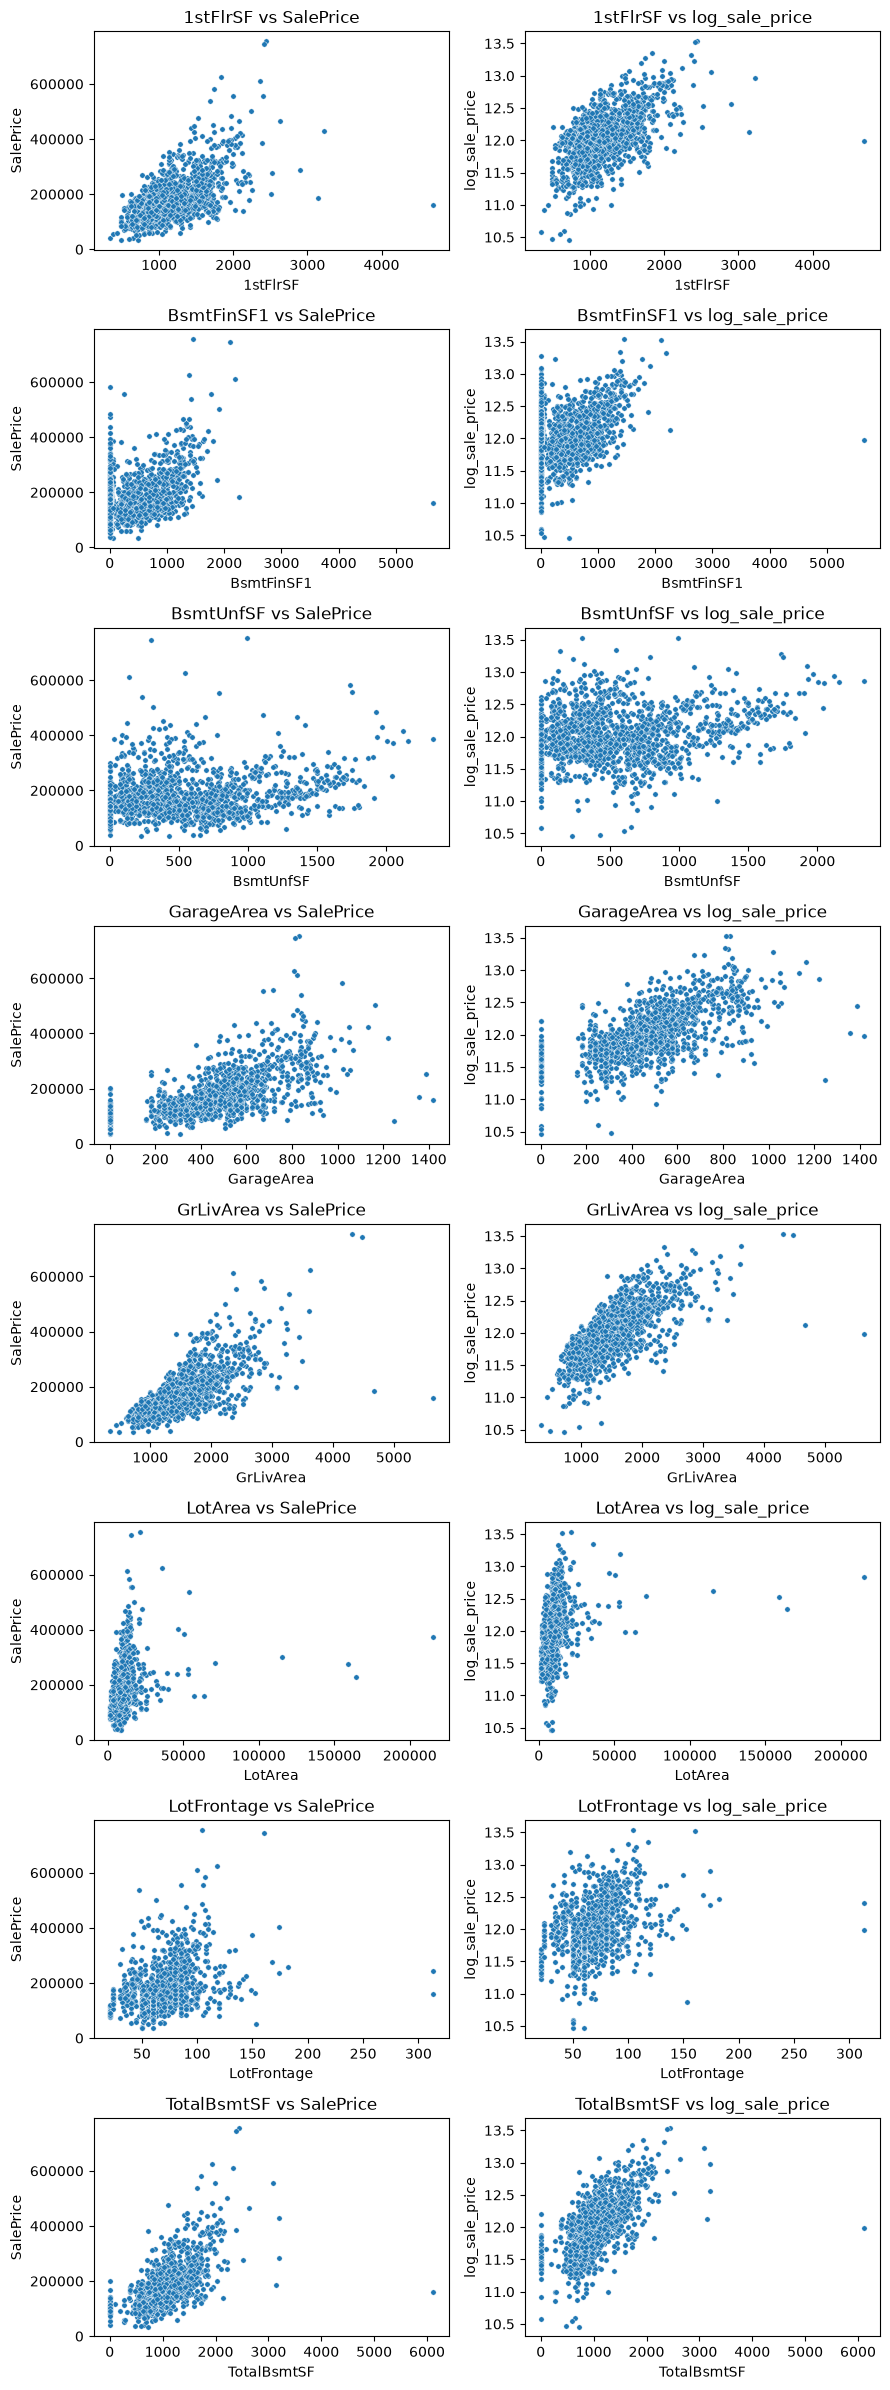

In [8]:
# scatter grid: size-driven columns, raw SalePrice vs log_sale_price side by side
n_rows = len(SIZE_COLS)
fig, axes = plt.subplots(n_rows, 2, figsize=(9, 3 * n_rows))
for row, col in enumerate(SIZE_COLS):
    sns.scatterplot(x=df_train[col], y=df_train["SalePrice"], ax=axes[row, 0], s=15)
    axes[row, 0].set_title(f"{col} vs SalePrice")
    sns.scatterplot(x=df_train[col], y=log_sale_price, ax=axes[row, 1], s=15)
    axes[row, 1].set_title(f"{col} vs log_sale_price")
plt.tight_layout()
plt.show()


Two questions per column, one per panel: **(1)** does having the amenity
at all shift price (`has` vs `none` boxplot)? **(2)** among houses that
have it, does more of it mean a higher price (scatter on the nonzero
subset)? Panels are sorted by `n_has` — the best-supported columns first,
the sparsest (a handful of nonzero rows) last, so a thin scatter reads as
"not enough data" rather than "no relationship."

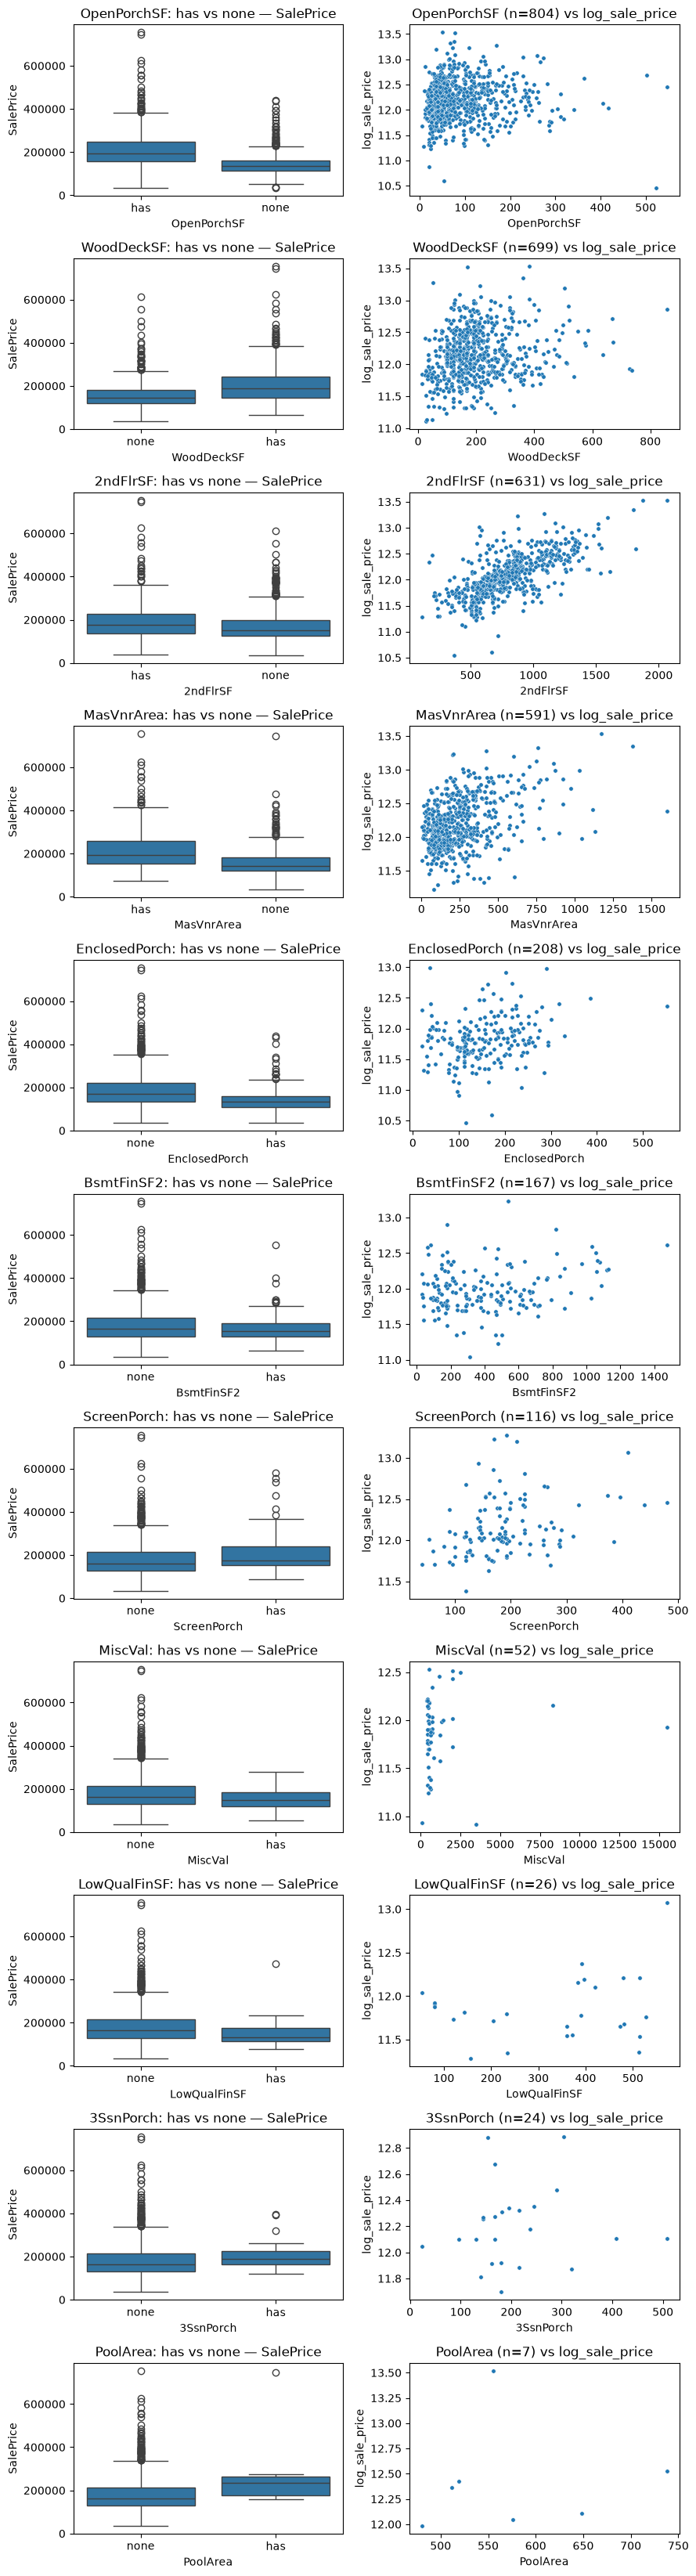

In [9]:
# has-X split for the continuous zero-inflated columns, sorted by n_has so
# the best-supported columns come first and the sparsest come last. MasVnrArea
# has 8 NaN rows (2_missingness.ipynb) — "unrecorded" isn't "no veneer", so
# those rows are excluded from the split explicitly rather than silently
# landing in "none" via NaN > 0 evaluating to False.
n_has = {
    col: (df_train[col].notna() & (df_train[col] > 0)).sum()
    for col in ZERO_INFLATED_CONTINUOUS
}
zero_inflated_by_n = sorted(ZERO_INFLATED_CONTINUOUS, key=lambda c: n_has[c], reverse=True)

n_rows = len(zero_inflated_by_n)
fig, axes = plt.subplots(n_rows, 2, figsize=(9, 3 * n_rows))
for row, col in enumerate(zero_inflated_by_n):
    present = df_train[col].notna()
    has_x = (df_train.loc[present, col] > 0).map({True: "has", False: "none"})
    sns.boxplot(x=has_x, y=df_train.loc[present, "SalePrice"], ax=axes[row, 0])
    axes[row, 0].set_title(f"{col}: has vs none — SalePrice")
    nonzero = present & (df_train[col] > 0)
    sns.scatterplot(x=df_train.loc[nonzero, col], y=log_sale_price[nonzero], ax=axes[row, 1], s=15)
    axes[row, 1].set_title(f"{col} (n={n_has[col]}) vs log_sale_price")
plt.tight_layout()
plt.show()


In [10]:
# same two questions as a table: price lift from having the amenity at all,
# and the Spearman correlation on the nonzero subset — sorted by n_has so
# the reliability of each row is visible before its numbers are
summary_rows = []
for col in zero_inflated_by_n:
    present = df_train[col].notna()
    has = present & (df_train[col] > 0)
    none = present & (df_train[col] == 0)
    summary_rows.append({
        "column": col,
        "n_has": has.sum(),
        "n_none": none.sum(),
        "median_has": df_train.loc[has, "SalePrice"].median(),
        "median_none": df_train.loc[none, "SalePrice"].median(),
        "nonzero_spearman": df_train.loc[has, col].corr(log_sale_price[has], method="spearman"),
    })
zero_inflated_summary = pd.DataFrame(summary_rows).set_index("column")
zero_inflated_summary["price_lift_pct"] = (
    zero_inflated_summary["median_has"] / zero_inflated_summary["median_none"] - 1
) * 100
zero_inflated_summary.round(2)


,n_has,n_none,median_has,median_none,nonzero_spearman,price_lift_pct
column,,,,,,
OpenPorchSF,804,656,192000.0,136700.0,0.16,40.45
WoodDeckSF,699,761,187000.0,144152.0,0.21,29.72
2ndFlrSF,631,829,177000.0,150000.0,0.70,18.00
MasVnrArea,591,861,192000.0,143000.0,0.33,34.27
EnclosedPorch,208,1252,133350.0,170000.0,0.25,-21.56
BsmtFinSF2,167,1293,154000.0,165000.0,0.12,-6.67
ScreenPorch,116,1344,175000.0,160000.0,0.32,9.38
MiscVal,52,1408,148000.0,164000.0,0.15,-9.76
LowQualFinSF,26,1434,131500.0,163945.0,0.11,-19.79


**Decision:**

- **Well-supported (n_has ≥ ~200): a real, consistent has-vs-none lift** —
  `OpenPorchSF` (+40%, n=804), `MasVnrArea` (+34%, n=591), `WoodDeckSF`
  (+30%, n=699), `2ndFlrSF` (+18%, n=631, and the strongest nonzero
  correlation at 0.70 — having *and* the size of the 2nd floor both matter).
  `EnclosedPorch` is the one well-supported column that goes the other way
  (-22% with a porch, n=208) — plausibly a confound with older/smaller
  houses rather than enclosed porches themselves hurting price.
- **Too sparse to trust (n_has < 30): descriptive only, not decision-grade**
  — `PoolArea` (n=7), `LowQualFinSF` (n=26), `3SsnPorch` (n=24). Their
  price-lift numbers (+44%, -20%, +16%) and nonzero scatters shouldn't be
  read as findings; a handful of rows can't support either a has-X flag or
  a transform decision, whatever the number says.
- **In between (n_has 50–170), directionally suggestive**: `ScreenPorch`
  (+9%, n=116), `BsmtFinSF2` (-7%, n=167), `MiscVal` (-10%, n=52) — weak
  or inconsistent lift, low nonzero correlation (≤0.32); not strong enough
  to flag as transform priorities on their own.
- **Boundary held:** describing the split, not deciding it — has-X flags
  and per-column transforms are still preprocessing's call, informed by
  this table.

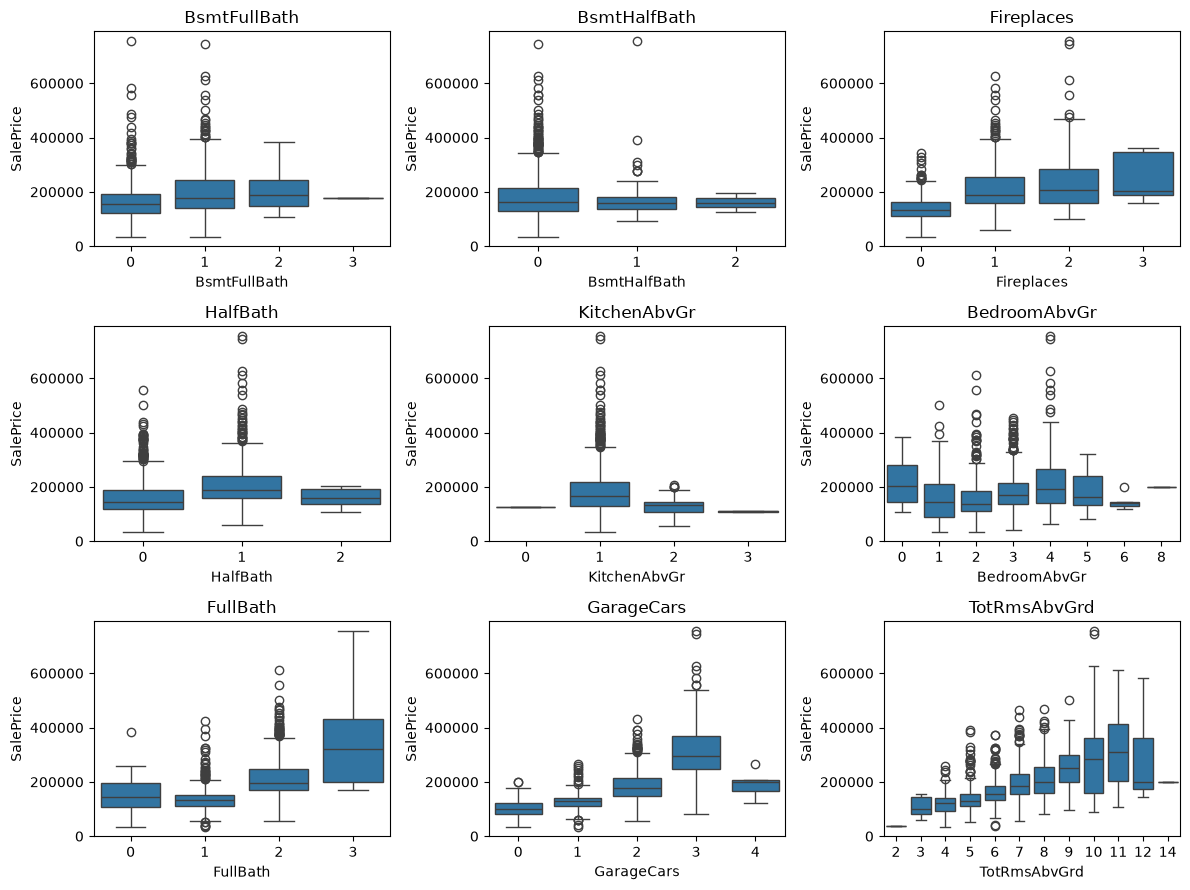

In [11]:
# low-cardinality counts: boxplot by level, ordered numerically, instead of
# a scatter with only a handful of x-positions. KitchenAbvGr and
# DISCRETE_COUNT_COLS ride along here for the chart type even though their
# skew isn't zero-inflation (lopsided mode, or just genuinely low
# cardinality) — see the notes above.
count_cols = ZERO_INFLATED_COUNTS + LOPSIDED_COUNTS + DISCRETE_COUNT_COLS
n_cols = 3
n_rows = -(-len(count_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
for ax, col in zip(axes.flat, count_cols):
    order = sorted(df_train[col].dropna().unique())
    sns.boxplot(data=df_train, x=col, y="SalePrice", order=order, ax=ax)
    ax.set_title(col)
for ax in axes.flat[len(count_cols):]:
    ax.set_visible(False)
plt.tight_layout()
plt.show()


In [12]:
# correlation table: numeric (raw values) + ordinal (documented-order encoding),
# Pearson and Spearman against log_sale_price, in one ranked table
numeric_corr = pd.DataFrame({
    "pearson": df_train[NUMERIC_COLS].corrwith(log_sale_price),
    "spearman": df_train[NUMERIC_COLS].corrwith(log_sale_price, method="spearman"),
})
numeric_corr["feature_type"] = "numeric"

ordinal_corr = pd.DataFrame({
    "pearson": ordinal_encoded.corrwith(log_sale_price),
    "spearman": ordinal_encoded.corrwith(log_sale_price, method="spearman"),
})
ordinal_corr["feature_type"] = "ordinal"

target_corr = pd.concat([numeric_corr, ordinal_corr])
target_corr["pearson_spearman_gap"] = (target_corr["spearman"] - target_corr["pearson"]).abs()
target_corr = target_corr.sort_values("spearman", key=abs, ascending=False)
target_corr


,pearson,spearman,feature_type,pearson_spearman_gap
OverallQual,0.817185,0.809829,ordinal,0.007356
GrLivArea,0.700927,0.731310,numeric,0.030383
GarageCars,0.680625,0.690711,numeric,0.010086
ExterQual,0.678840,0.684014,ordinal,0.005174
KitchenQual,0.667893,0.672849,ordinal,0.004955
BsmtQual,0.653510,0.664393,ordinal,0.010882
YearBuilt,0.586570,0.652682,numeric,0.066111
GarageArea,0.650888,0.649379,numeric,0.001509
FullBath,0.594771,0.635957,numeric,0.041186
TotalBsmtSF,0.612134,0.602725,numeric,0.009409


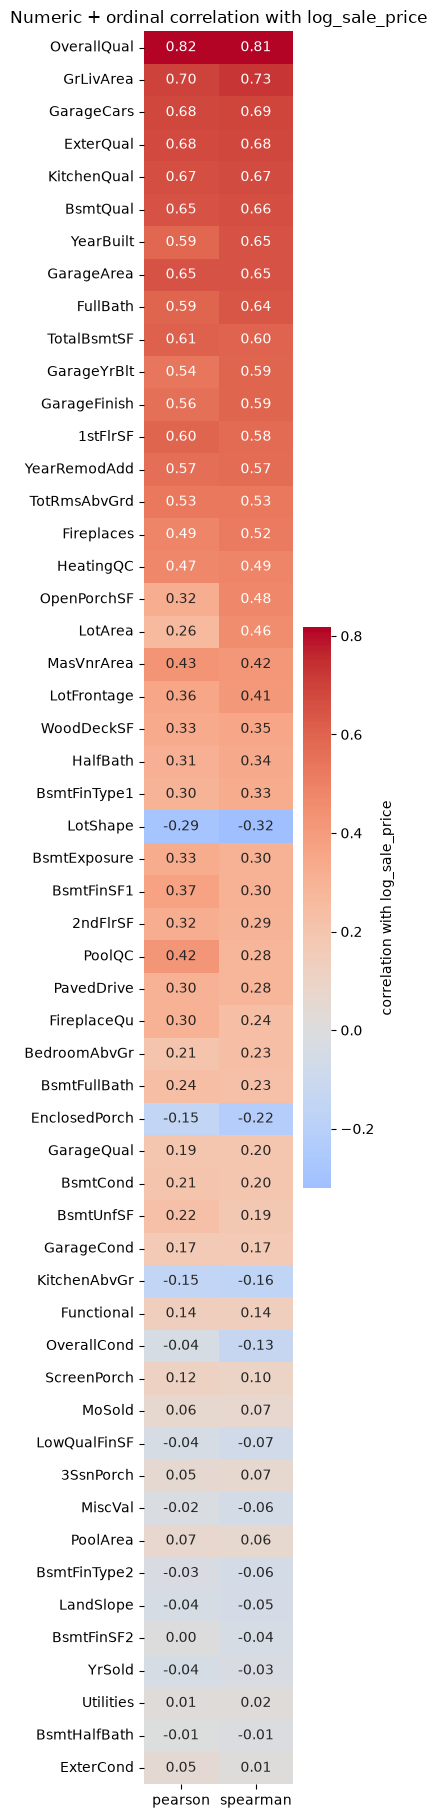

In [13]:
# same table as a heatmap — already sorted by |spearman|, so this reads
# top (strongest) to bottom (weakest) at a glance
fig, ax = plt.subplots(figsize=(4, 0.32 * len(target_corr) + 1))
sns.heatmap(
    target_corr[["pearson", "spearman"]],
    annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax,
    cbar_kws={"label": "correlation with log_sale_price"},
)
ax.set_title("Numeric + ordinal correlation with log_sale_price")
plt.tight_layout()
plt.show()


In [14]:
# biggest Pearson/Spearman gaps — sign of a real but non-linear relationship
target_corr.sort_values("pearson_spearman_gap", ascending=False).head(10)


,pearson,spearman,feature_type,pearson_spearman_gap
LotArea,0.257320,0.456461,numeric,0.199141
OpenPorchSF,0.321053,0.477561,numeric,0.156507
PoolQC,0.422829,0.283473,ordinal,0.139356
OverallCond,-0.036868,-0.129325,ordinal,0.092456
BsmtFinSF1,0.372023,0.301871,numeric,0.070152
EnclosedPorch,-0.149050,-0.218394,numeric,0.069343
YearBuilt,0.586570,0.652682,numeric,0.066111
FireplaceQu,0.304395,0.241431,ordinal,0.062965
LotFrontage,0.355879,0.409076,numeric,0.053197
GarageYrBlt,0.541073,0.593788,numeric,0.052716


### Temporal columns

Mean/median price trend by `YearBuilt`/`YearRemodAdd`/`GarageYrBlt`, and
price distribution by `MoSold`/`YrSold`. `GarageYrBlt` is NaN for the 81
rows with no garage ([2_missingness.ipynb](2_missingness.ipynb)) — those
rows are dropped rather than zero-filled, so its trend line is implicitly
conditional on having a garage, not a statement about the full population.

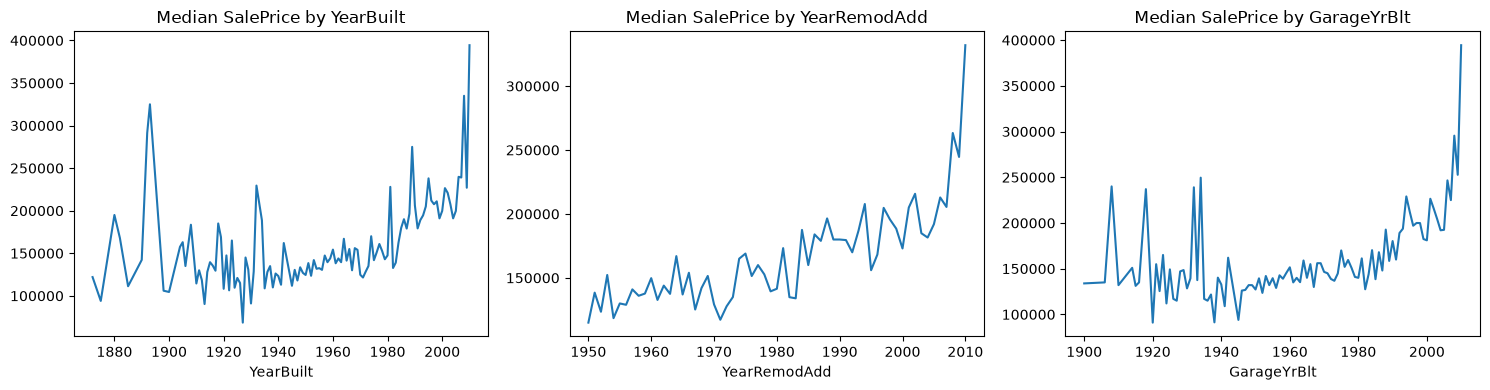

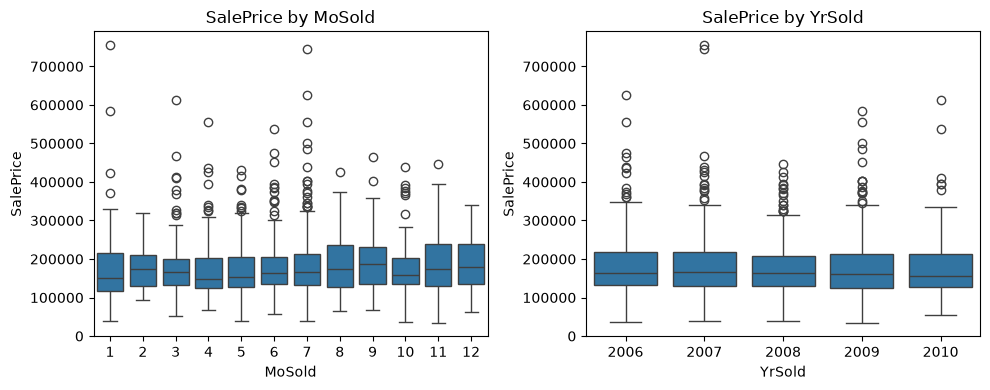

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["YearBuilt", "YearRemodAdd", "GarageYrBlt"]):
    yearly = df_train.dropna(subset=[col]).groupby(col)["SalePrice"].median()
    yearly.plot(ax=ax)
    ax.set_title(f"Median SalePrice by {col}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df_train, x="MoSold", y="SalePrice", ax=axes[0])
axes[0].set_title("SalePrice by MoSold")
sns.boxplot(data=df_train, x="YrSold", y="SalePrice", ax=axes[1])
axes[1].set_title("SalePrice by YrSold")
plt.tight_layout()
plt.show()


## Ordinal features

`SalePrice` by level, x-axis ordered worst → best per `ORDER` (documented
in the scaffolding above, same map used for the ordinal Spearman
correlation). Only `log_sale_price` needs computing once per notebook —
monotonicity is invariant under a log transform, so a level order that's
non-decreasing in raw `SalePrice` is non-decreasing in `log_sale_price`
too, and vice versa. No need to plot both.

Each x-tick is annotated with its level's row count, since
[3_univariate.ipynb](3_univariate.ipynb) already flagged 13 of these 21
columns as having a thin tail level (<1% of rows) — a box drawn over 1-3
points looks the same on the page as one drawn over 800, and shouldn't be
read the same way.

**Scope:** flag non-monotonic level orders and thin-level reliability —
no merging, encoding, or dropping here, that's preprocessing.

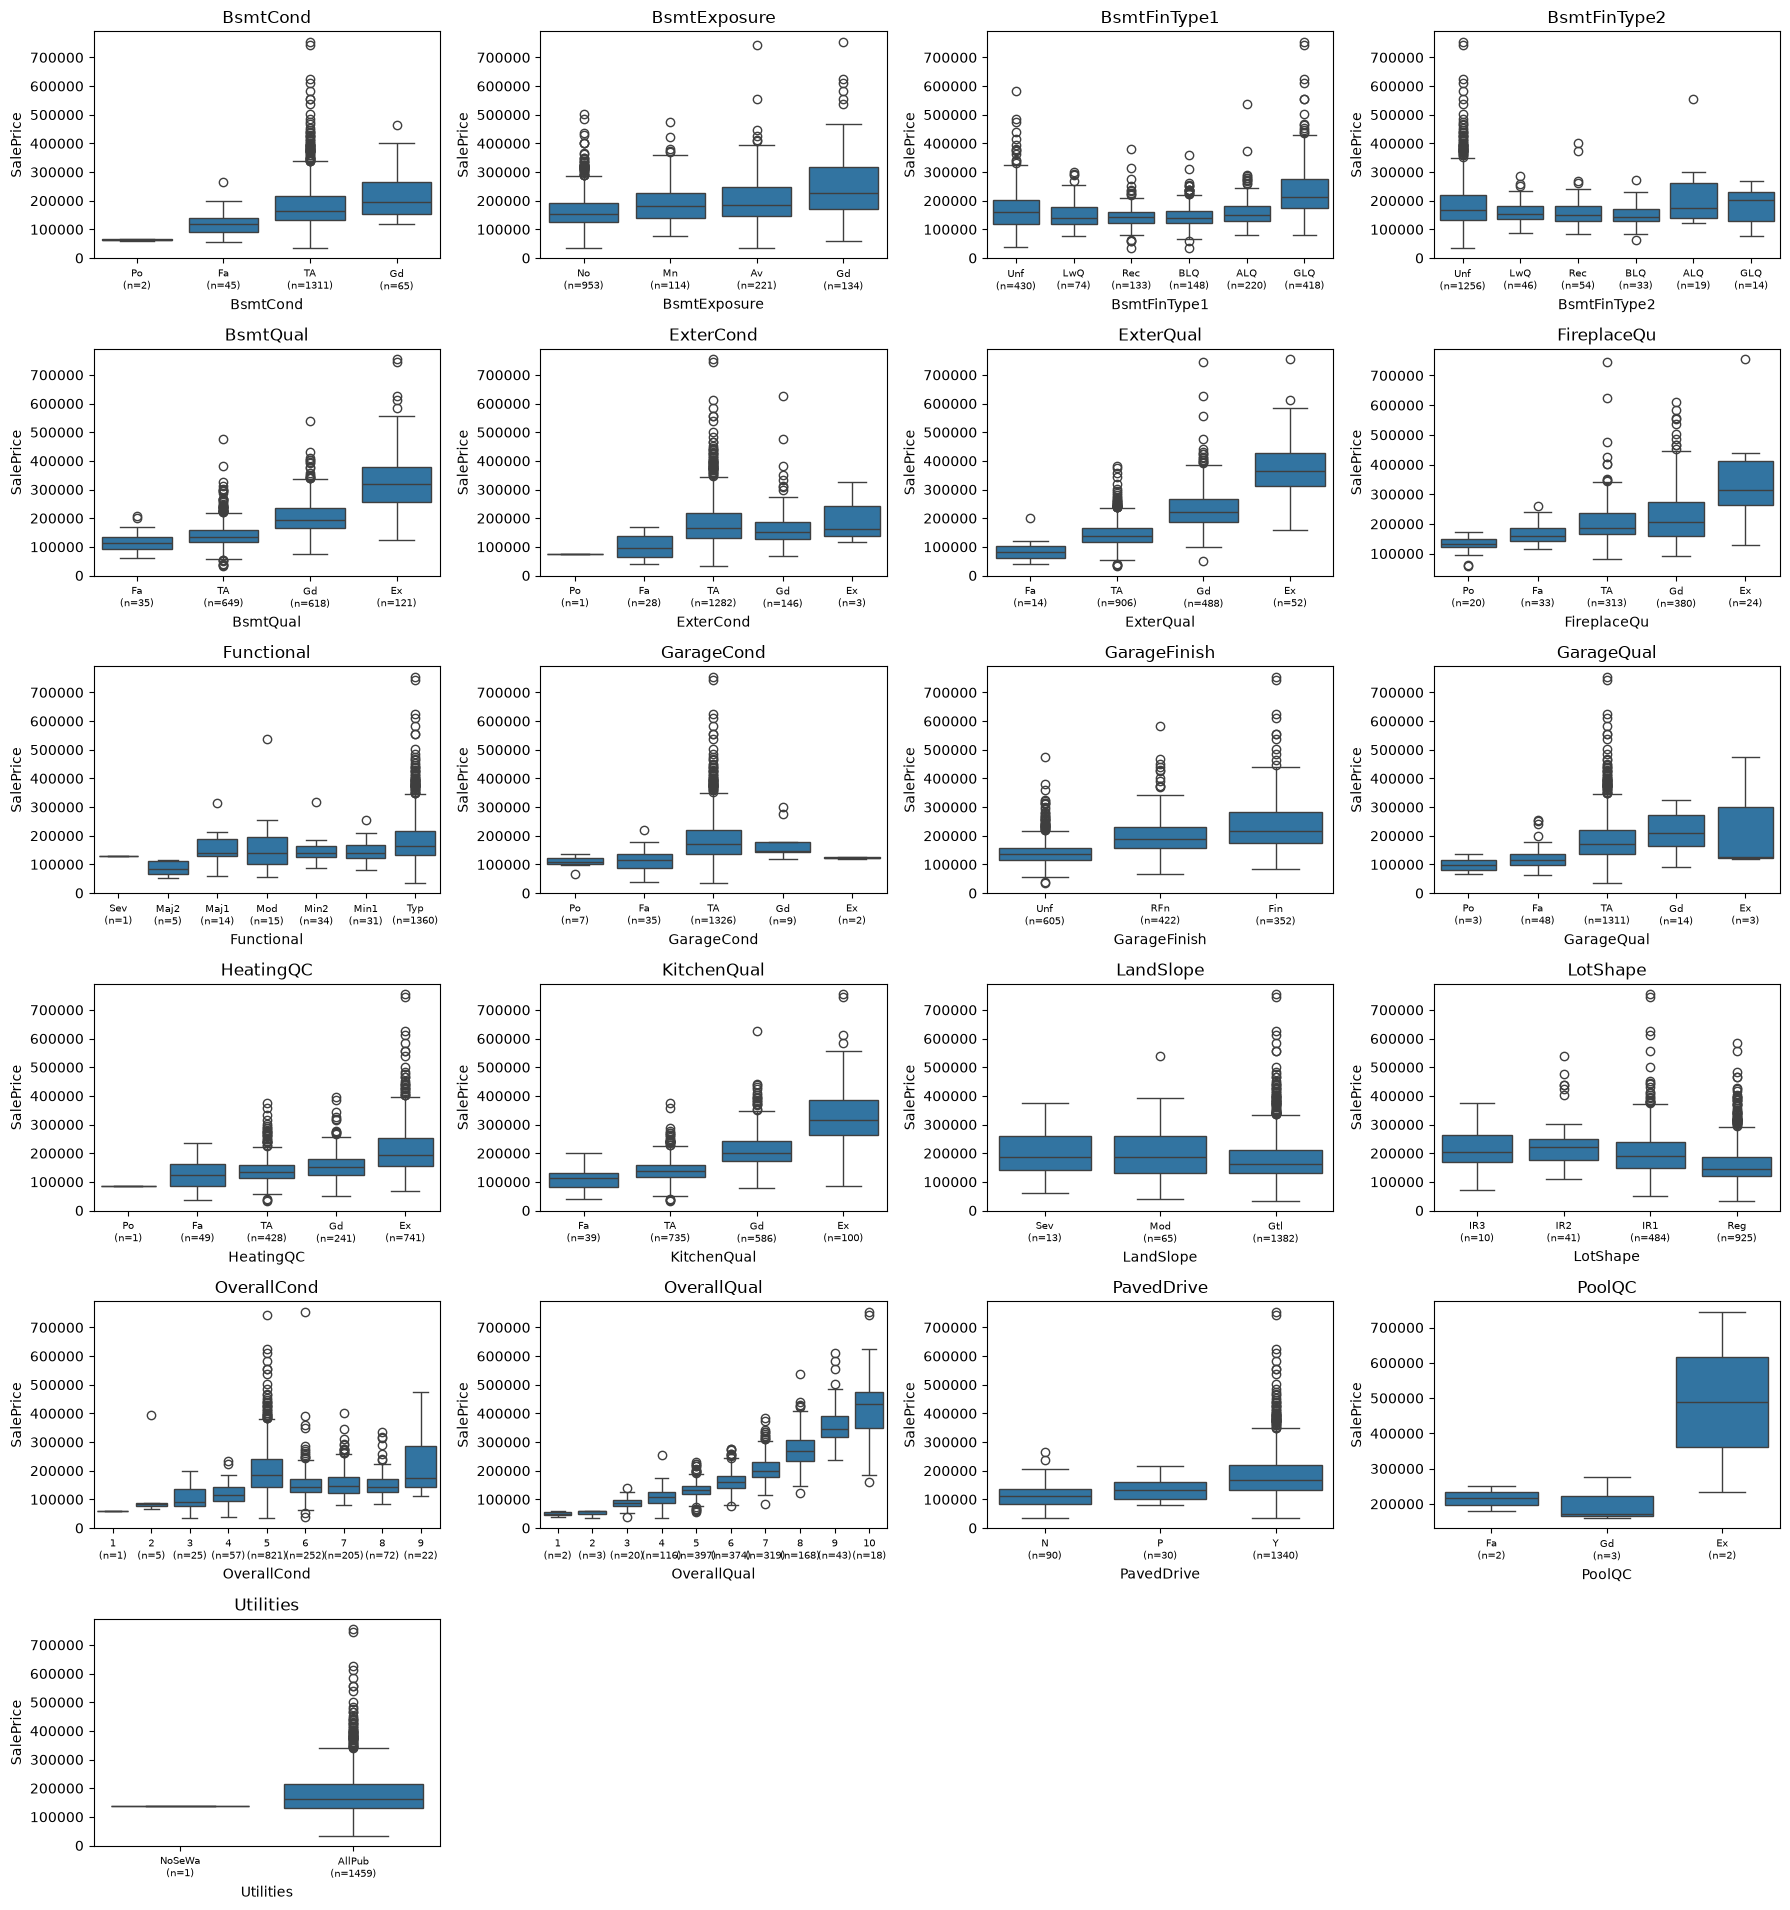

In [16]:
n_cols = 4
n_rows = -(-len(ORDINAL_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.5 * n_cols, 3.2 * n_rows))

for ax, col in zip(axes.flat, ORDINAL_COLS):
    order = [lvl for lvl in ORDER[col] if lvl in df_train[col].unique()]
    counts = df_train[col].value_counts()
    sns.boxplot(data=df_train, x=col, y="SalePrice", order=order, ax=ax)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([f"{lvl}\n(n={counts[lvl]})" for lvl in order], fontsize=7)
    ax.set_title(col)

for ax in axes.flat[len(ORDINAL_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [17]:
# monotonicity check: does median SalePrice move consistently with the
# documented level order? NaN excluded (structural absence, see
# 2_missingness.ipynb) — same convention as the ordinal Spearman encoding.
non_monotonic = []
for col in ORDINAL_COLS:
    order = [lvl for lvl in ORDER[col] if lvl in df_train[col].unique()]
    median_by_level = df_train.groupby(col)["SalePrice"].median().reindex(order)
    count_by_level = df_train.groupby(col)["SalePrice"].count().reindex(order)
    diffs = median_by_level.diff().dropna()
    if not (diffs >= 0).all():
        non_monotonic.append(col)
        print(f"--- {col} (not monotonic) ---")
        print(pd.DataFrame({"n": count_by_level, "median_price": median_by_level}))
        print()

print(f"{len(non_monotonic)} of {len(ORDINAL_COLS)} columns are not monotonic: {non_monotonic}")


--- BsmtFinType1 (not monotonic) ---
                n  median_price
BsmtFinType1                   
Unf           430      161750.0
LwQ            74      139000.0
Rec           133      142000.0
BLQ           148      139100.0
ALQ           220      149250.0
GLQ           418      213750.0

--- BsmtFinType2 (not monotonic) ---
                 n  median_price
BsmtFinType2                    
Unf           1256      167000.0
LwQ             46      154000.0
Rec             54      148750.0
BLQ             33      143000.0
ALQ             19      174900.0
GLQ             14      203125.0

--- ExterCond (not monotonic) ---
              n  median_price
ExterCond                    
Po            1       76500.0
Fa           28       95750.0
TA         1282      167370.0
Gd          146      151250.0
Ex            3      161000.0

--- Functional (not monotonic) ---
               n  median_price
Functional                    
Sev            1      129000.0
Maj2           5       85000.0


In [18]:
# thinnest observed level per column, and whether its price reads as signal
# or noise from a handful of rows — same question asked of the zero-inflated
# numeric columns above, now applied to the ordinal lopsided-level flags
rows = []
for col in ORDINAL_COLS:
    order = [lvl for lvl in ORDER[col] if lvl in df_train[col].unique()]
    count_by_level = df_train.groupby(col)["SalePrice"].count().reindex(order)
    median_by_level = df_train.groupby(col)["SalePrice"].median().reindex(order)
    thin_level = count_by_level.idxmin()
    rows.append({
        "column": col,
        "thin_level": thin_level,
        "thin_n": count_by_level[thin_level],
        "thin_median": median_by_level[thin_level],
    })
thin_level_summary = pd.DataFrame(rows).set_index("column")
thin_level_summary["overall_median"] = df_train["SalePrice"].median()
thin_level_summary.sort_values("thin_n")


,thin_level,thin_n,thin_median,overall_median
column,,,,
ExterCond,Po,1,76500.0,163000.0
Functional,Sev,1,129000.0,163000.0
HeatingQC,Po,1,87000.0,163000.0
OverallCond,1,1,61000.0,163000.0
Utilities,NoSeWa,1,137500.0,163000.0
PoolQC,Fa,2,215500.0,163000.0
GarageCond,Ex,2,124000.0,163000.0
BsmtCond,Po,2,64000.0,163000.0
OverallQual,1,2,50150.0,163000.0


**Decision:**

- **Utilities resolved as planned:** its thinnest level (`NoSeWa`) has
  `n=1` — the same single row flagged in 3_univariate as 99.93% `AllPub`.
  No price comparison built on one row can confirm or overturn a drop
  decision; it's undecidable by bivariate means and stays a drop candidate
  on variance grounds alone, unchanged from 3_univariate.
- **Real, well-supported inversions** — median price does *not* increase
  with documented level, and the level driving the inversion has hundreds
  of rows, not a handful:
  - `OverallCond`: peaks at level 5 (n=821, median $185k) then *drops* at
    levels 6-8 (n=252/205/72, medians $142.75k/$145k/$142.5k) before
    partially recovering at 9. `OverallCond` and `OverallQual` are
    frequently conflated in this dataset — condition 5 is the de facto
    "typical/average" bucket most houses land in regardless of quality,
    which plausibly explains why it outprices the nominally-better 6-8.
  - `LotShape`: irregular lots (`IR1`, n=484, median $189k) outprice
    regular ones (`Reg`, n=925, median $146k) — the reverse of "regular is
    simplest, ought to command a premium." Likely confounded with
    neighborhood/lot size rather than shape itself driving price.
  - `LandSlope`: non-gentle slopes (`Sev`/`Mod`, n=13/65) both outprice
    `Gtl` (n=1382) — same story, probably a confound (hillier lots
    clustering in pricier neighborhoods) rather than slope itself.
  - `BsmtFinType1`/`BsmtFinType2`: mostly monotonic but `Unf` (n=430/1256)
    outprices several mid-tier finish types — an unfinished basement
    isn't penalized the way the order implies.
- **Inversions that are thin-level noise, not signal** — driven by a
  level with single-digit `n`: `ExterCond` (`Po` n=1), `Functional`
  (`Sev` n=1), `HeatingQC` (`Po` n=1), `BsmtCond` (`Po` n=2), `GarageCond`
  (`Ex` n=2), `OverallQual` (`1` n=2), `PoolQC` (`Fa` n=2), `GarageQual`
  (`Po` n=3). These match 3_univariate's lopsided-level list — the thin
  tail is still just thin, not a distinct price signal.
- **Boundary held:** flags only — no level merging, encoding, or dropping
  applied here. The real (well-supported) inversions are candidates for
  preprocessing to investigate further (likely via a neighborhood/size
  confound check) rather than assumed to be genuine quality effects.

## Nominal features

No documented order for these 25 columns, so the ranking tools differ from
the ordinal section: **η² (correlation ratio)** — the share of
`log_sale_price`'s variance explained by category membership, roughly the
categorical analog of R² — replaces Spearman/Pearson as the ranked-strength
table, and boxplots are sorted by median price ascending (the "order" a
nominal column doesn't otherwise have) instead of a documented scale.

**NaN handling differs by table, deliberately:** the boxplots and the
rare-category table below exclude NaN, same convention as the ordinal
section (structural absence — no alley, no fence, no garage — is
2_missingness.ipynb's territory, not re-litigated here). η² is computed
*with* NaN as its own group, because that's a read-only variance
decomposition over the groups as observed, not an encoding decision — it
answers "does knowing this category, including 'none', predict price,"
which is a different question than "how do the observed levels compare."

**Scope:** flag associations, rare categories, and — for the near-zero-
variance columns 3_univariate flagged as drop candidates — whether the
minority levels are decidable at all; no encoding, bucketing, or dropping
here.

In [19]:
# eta^2 per nominal column: share of log_sale_price variance explained by
# category membership. Computed with NaN as its own group (dropna=False) —
# a read-only variance decomposition, not an encoding of the data.
grand_mean = log_sale_price.mean()
ss_total = ((log_sale_price - grand_mean) ** 2).sum()

eta2_rows = []
for col in NOMINAL_COLS:
    groups = log_sale_price.groupby(df_train[col], dropna=False)
    ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for _, g in groups)
    eta2_rows.append({
        "column": col,
        "eta2": ss_between / ss_total,
        "n_categories": groups.ngroups,
    })

nominal_assoc = pd.DataFrame(eta2_rows).set_index("column").sort_values("eta2", ascending=False)
nominal_assoc.round(4)


,eta2,n_categories
column,,
Neighborhood,0.5708,25
GarageType,0.3346,7
MSSubClass,0.3301,15
Foundation,0.3037,6
MasVnrType,0.1881,4
Exterior1st,0.1815,15
MSZoning,0.1758,5
Exterior2nd,0.1715,16
SaleCondition,0.1290,6


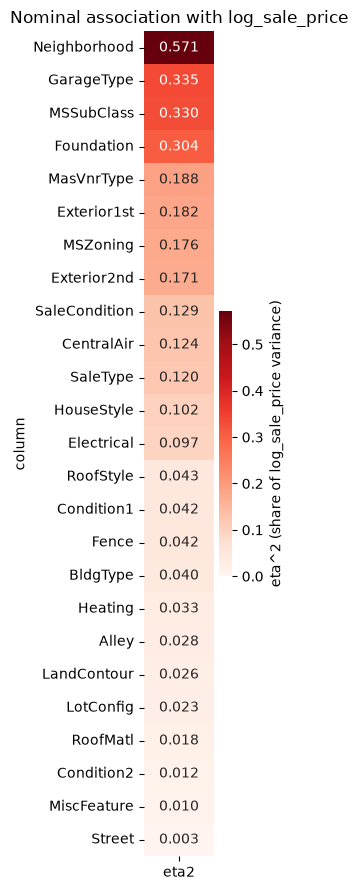

In [20]:
# same table as a heatmap — eta^2 has no negative direction (unlike
# correlation), so a sequential colormap rather than a diverging one
fig, ax = plt.subplots(figsize=(3, 0.32 * len(nominal_assoc) + 1))
sns.heatmap(
    nominal_assoc[["eta2"]],
    annot=True, fmt=".3f", cmap="Reds", vmin=0, ax=ax,
    cbar_kws={"label": "eta^2 (share of log_sale_price variance)"},
)
ax.set_title("Nominal association with log_sale_price")
plt.tight_layout()
plt.show()


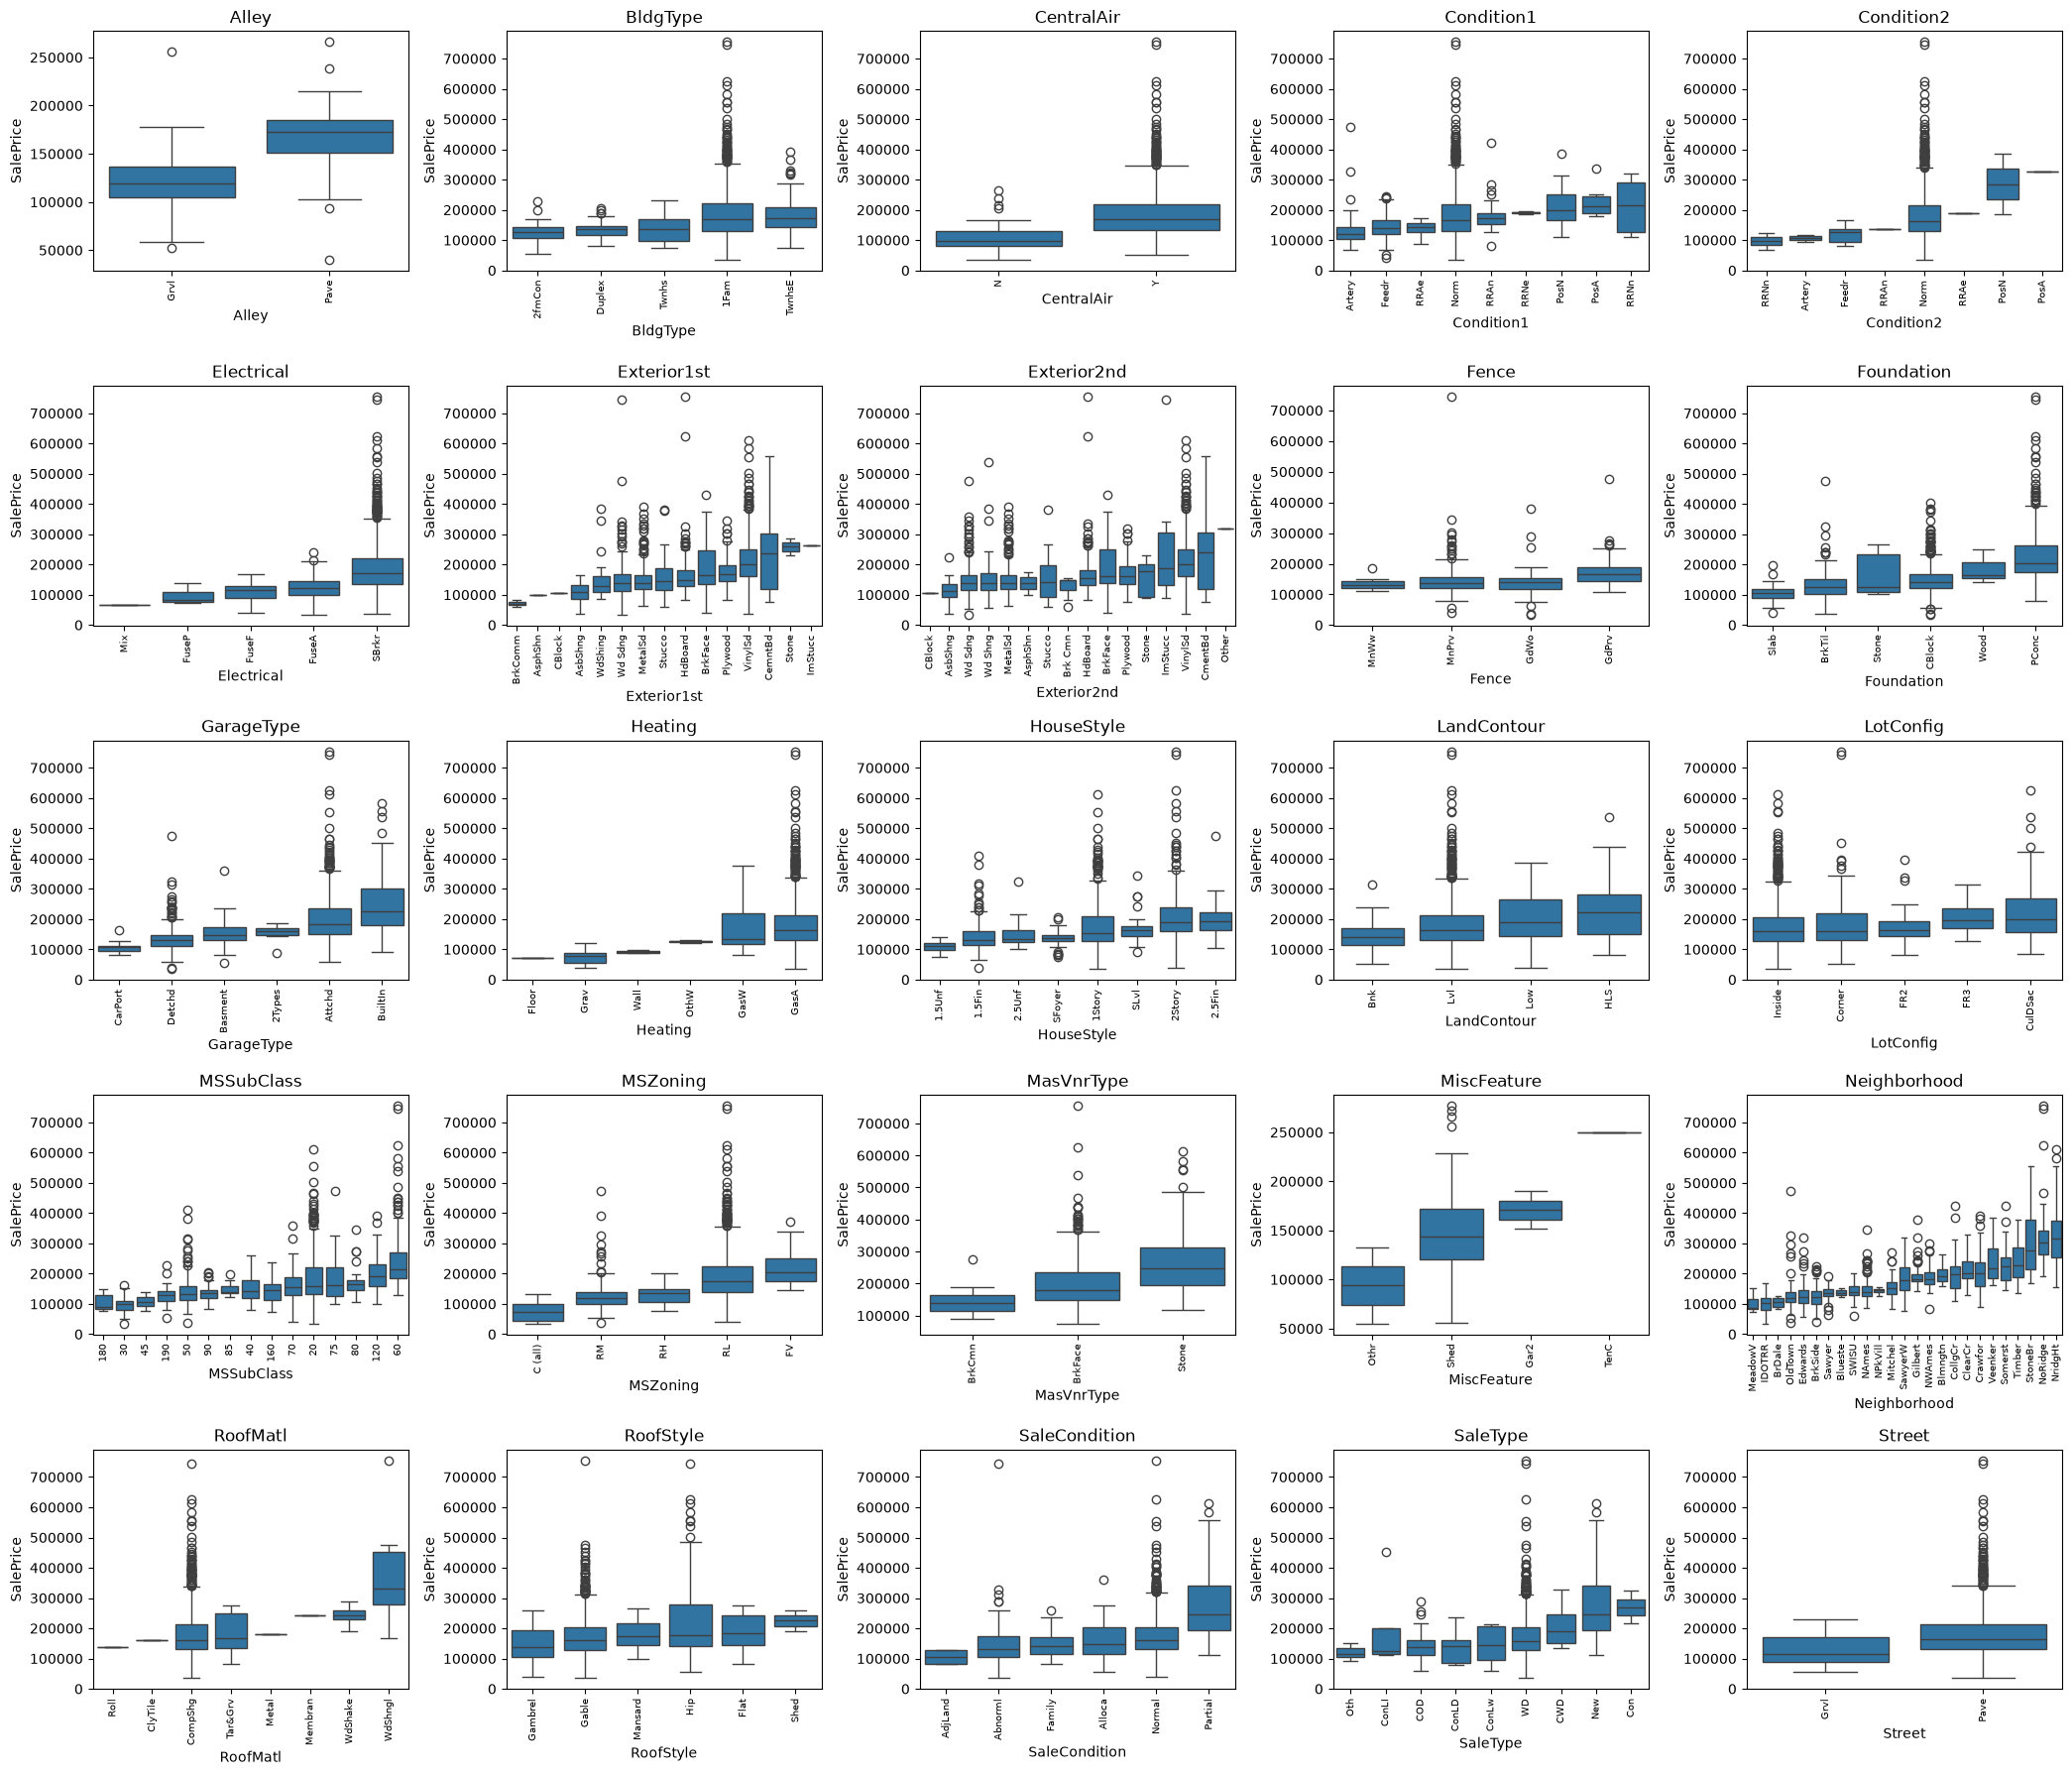

In [21]:
# sorted by median price ascending — nominal columns have no documented
# order, so this is the closest analog to the ordinal section's ORDER axis.
# NaN dropped automatically (groupby/order both skip it), consistent with
# the ordinal section's convention.
n_cols = 5
n_rows = -(-len(NOMINAL_COLS) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4.2 * n_cols, 3.6 * n_rows))

for ax, col in zip(axes.flat, NOMINAL_COLS):
    order = df_train.groupby(col)["SalePrice"].median().sort_values().index
    sns.boxplot(data=df_train, x=col, y="SalePrice", order=order, ax=ax)
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=90, labelsize=7)

for ax in axes.flat[len(NOMINAL_COLS):]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()


In [22]:
# thinnest observed category per column, same reliability check as the
# ordinal thin-level table — cross-references 3_univariate's 18
# rare-category flags against actual price
rows = []
for col in NOMINAL_COLS:
    counts = df_train[col].value_counts()
    thin_level = counts.idxmin()
    rows.append({
        "column": col,
        "thin_level": thin_level,
        "thin_n": counts.min(),
        "thin_median": df_train.loc[df_train[col] == thin_level, "SalePrice"].median(),
        "n_categories": len(counts),
    })
nominal_thin_summary = pd.DataFrame(rows).set_index("column")
nominal_thin_summary["overall_median"] = df_train["SalePrice"].median()
nominal_thin_summary.sort_values("thin_n")


,thin_level,thin_n,thin_median,n_categories,overall_median
column,,,,,
Exterior2nd,Other,1,319000.0,16,163000.0
Exterior1st,AsphShn,1,100000.0,15,163000.0
Electrical,Mix,1,67000.0,5,163000.0
Condition2,PosA,1,325000.0,8,163000.0
Heating,Floor,1,72500.0,6,163000.0
MiscFeature,TenC,1,250000.0,4,163000.0
RoofMatl,Metal,1,180000.0,8,163000.0
Condition1,RRNe,2,190750.0,9,163000.0
Neighborhood,Blueste,2,137500.0,25,163000.0


In [23]:
# the 4 remaining near-zero-variance drop candidates from 3_univariate
# (Utilities already resolved in the ordinal section — same question here:
# is the minority level(s) actually decidable, or too thin to trust?
drop_candidates = {"Street": "Pave", "Condition2": "Norm", "RoofMatl": "CompShg", "Heating": "GasA"}

for col, majority in drop_candidates.items():
    print(f"--- {col} (majority: {majority}) ---")
    print(df_train.groupby(col)["SalePrice"].agg(["count", "median"]).sort_values("count", ascending=False))
    is_majority = df_train[col] == majority
    maj_med = df_train.loc[is_majority, "SalePrice"].median()
    min_n = (~is_majority).sum()
    min_med = df_train.loc[~is_majority, "SalePrice"].median()
    lift = 100 * (min_med / maj_med - 1)
    print(f"bucketed minority: n={min_n}, median={min_med:.0f}, lift vs majority={lift:+.1f}%\n")


--- Street (majority: Pave) ---
        count    median
Street                 
Pave     1454  163000.0
Grvl        6  114250.0
bucketed minority: n=6, median=114250, lift vs majority=-29.9%

--- Condition2 (majority: Norm) ---
            count    median
Condition2                 
Norm         1445  163500.0
Feedr           6  127500.0
Artery          2  106500.0
PosN            2  284875.0
RRNn            2   96750.0
PosA            1  325000.0
RRAe            1  190000.0
RRAn            1  136905.0
bucketed minority: n=15, median=128000, lift vs majority=-21.7%

--- RoofMatl (majority: CompShg) ---
          count    median
RoofMatl                 
CompShg    1434  162000.0
Tar&Grv      11  167000.0
WdShngl       6  332500.0
WdShake       5  242000.0
Metal         1  180000.0
Membran       1  241500.0
ClyTile       1  160000.0
Roll          1  137000.0
bucketed minority: n=26, median=234750, lift vs majority=+44.9%

--- Heating (majority: GasA) ---
         count    median
Heating

**Decision:**

- **Strongest nominal predictors:** `Neighborhood` dominates (η²=0.57 —
  location alone explains over half the variance in `log_sale_price`),
  followed by `GarageType` (0.33), `MSSubClass` (0.33, the dwelling-type
  code — confirms it needed the nominal branch, not a numeric one),
  `Foundation` (0.30). These four are the columns most worth getting the
  encoding right for.
- **Near-noise nominal columns:** `Street` (η²=0.003), `Condition2`
  (0.012), `MiscFeature` (0.010) — barely more predictive than the
  near-zero-variance drop candidates below, despite not being flagged as
  such; low cardinality alone doesn't explain it (`RoofMatl`, also a drop
  candidate, has 8 categories and still lands near the bottom at 0.018).
- **The 4 remaining drop candidates, resolved individually** (Utilities
  already settled in the ordinal section — same question, different
  answer per column):
  - **`Street`**: minority (`Grvl`, n=6) prices 30% below `Pave` — a
    plausible, directionally clean signal, but n=6 is too thin to call it
    decided either way. Genuinely borderline.
  - **`Condition2`**: bucketing all 7 minority levels averages to -22%,
    but the individual levels split both directions at n=1-2 each
    (`PosA`/`PosN` near a positive feature run $285-325k, `RRNn`/`Artery`
    near $97-107k) — the bucketed number hides a real bidirectional
    pattern that no single level has enough rows to confirm. Closest of
    the four to Utilities' "undecidable" case.
  - **`RoofMatl`**: bucketed minority is **44.9% above** `CompShg`, driven
    consistently by `WdShngl` (n=6, $332.5k) and `WdShake` (n=5, $242k) —
    premium wood roofing, not noise from one row. Argues against a flat
    drop; if anything, preserving a "premium wood roof" flag carries more
    signal than the column's low η² (0.018) suggests on its own.
  - **`Heating`**: bucketed minority is consistently 21-56% below `GasA`
    across all 5 sub-levels (`GasW`/`Grav`/`Wall`/`OthW`/`Floor`, combined
    n=32) — the most internally consistent of the four, and the best
    candidate for bucketing into `AllPub`-style "modern gas forced-air vs.
    other" rather than dropping.
- **`MSSubClass`'s unseen category** (`150`, appears in test, never in
  train — 3_univariate) is unchanged by this notebook; still needs an
  explicit handling strategy at encoding time.
- **Boundary held:** every number above describes what's in the data —
  no bucketing, dropping, or encoding decision is made here. Preprocessing
  inherits a specific, reasoned recommendation per column instead of a
  flat "5 near-zero-variance columns, drop them."

## Summary

| Section | Columns | Key finding |
|---|---|---|
| Numeric | 33 (8 size-driven, 11 zero-inflated continuous, 9 low-cardinality counts, 5 temporal) | `OverallQual`/`GrLivArea`/`GarageCars` lead the combined numeric+ordinal Spearman ranking; `LotArea`/`OpenPorchSF`/`PoolQC`/`OverallCond` show the largest Pearson-Spearman gaps (non-linear-but-real relationships) |
| Numeric — zero-inflated | 11 continuous, split by n_has | 5 well-supported (`OpenPorchSF` +40%, `MasVnrArea` +34%, `WoodDeckSF` +30%, `2ndFlrSF` +18%, `EnclosedPorch` -22%); 3 too sparse to trust (`PoolArea` n=7, `LowQualFinSF` n=26, `3SsnPorch` n=24) |
| Ordinal | 21 | 10/21 not monotonic; 4 are real, well-supported inversions (`OverallCond`, `LotShape`, `LandSlope`, `BsmtFinType1`/`2` — likely neighborhood/size confounds, not genuine quality effects); 8 are thin-level noise (n≤3, matches 3_univariate's lopsided flags) |
| Nominal | 25 | η² ranking: `Neighborhood` dominates (0.57 — over half of `log_sale_price`'s variance), then `GarageType`/`MSSubClass`/`Foundation` (~0.30-0.33); `Street`/`Condition2`/`MiscFeature`/`RoofMatl` sit near zero |

**Drop candidates revised from 3_univariate's flat list of 5, now decided individually:**

- **`Utilities`**: undecidable (n=1 minority) — stays a drop candidate on variance grounds alone, unchanged.
- **`Street`**: borderline — real-looking -30% direction but n=6, too thin to commit either way.
- **`Condition2`**: closest to genuinely undecidable — bucketed minority masks a real bidirectional split at n=1-2 per level.
- **`RoofMatl`**: **reversed from "drop" to "bucket/preserve"** — minority is 45% *above* the majority, driven consistently by `WdShngl`/`WdShake` (premium wood roofing), not noise.
- **`Heating`**: **reversed from "drop" to "bucket"** — minority is consistently 21-56% below `GasA` across all 5 sub-levels (n=32), the cleanest bucket case of the four.

**Other candidates carried forward:**

- **Transform candidates (numeric, 8 `SIZE_COLS`)**: `LotArea`, `LotFrontage`, `GrLivArea`, `TotalBsmtSF`, `1stFlrSF`, `BsmtFinSF1`, `BsmtUnfSF`, `GarageArea` — log/Box-Cox, per the skew flags from 3_univariate plus this notebook's Pearson-Spearman gaps.
- **Has-X flag + transform on nonzero (5 well-supported zero-inflated)**: `OpenPorchSF`, `MasVnrArea`, `WoodDeckSF`, `2ndFlrSF`, `EnclosedPorch`.
- **Presence-flag only, don't model magnitude (3 too-sparse zero-inflated)**: `PoolArea`, `LowQualFinSF`, `3SsnPorch` — too few nonzero rows to support a size relationship, whatever this notebook's numbers show.
- **Bucket candidates (ordinal, 8 thin-level-noise columns)**: `ExterCond`, `Functional`, `HeatingQC`, `BsmtCond`, `GarageCond`, `OverallQual`, `PoolQC`, `GarageQual` — merge the single/few-row tail level at encoding time, per 3_univariate's original 12 (minus the 4 that turned out to be real, well-supported inversions worth investigating rather than merging away).
- **Investigate before encoding (ordinal, 4 well-supported inversions)**: `OverallCond`, `LotShape`, `LandSlope`, `BsmtFinType1`/`2` — the price relationship isn't a clean function of the documented order; worth checking against `Neighborhood`/lot size for a confound before choosing an encoding.
- **Bucket candidates (nominal)**: 3_univariate's 18 rare-category flags, refined here — `RoofMatl` and `Heating` specifically (see above), plus the general rare-tail columns (`Neighborhood`, `Exterior1st`/`Exterior2nd`, `Condition1`, `RoofStyle`, `SaleType`, `Foundation`) where η² shows the column matters enough to be worth encoding carefully rather than dropping tail levels blind.
- **Unseen-category handling**: `MSSubClass`'s `150` (test-only, per 3_univariate) — unchanged, still needs an explicit strategy (e.g. `handle_unknown="ignore"`).
- **Boundary held throughout**: every flag in this notebook describes an association or a reliability check — no transform, merge, bucket, or drop was actually applied. Preprocessing inherits column-by-column reasoning instead of a flat rule.